In [1]:
from cogent3.maths.matrix_exponential_integration import expected_number_subs
import matplotlib.pyplot as plt
import paths
import pandas as pd

import pickle

import re

In [2]:
#function to parse the alignment lenght

def parse_alignment_length(s: str, fmt: str = "{:.6e}") -> str:
    """
    Parse strings like "alignment length: X" and return X formatted in scientific notation.

    Parameters
    - s: input string containing a token like "alignment length: 12345"
    - fmt: a format string compatible with float.format, default "{:.6e}" (6 decimals in exp notation)

    Returns
    - str: the parsed number formatted according to `fmt` (scientific notation by default)

    Raises ValueError if the token is not found.
    """
    m = re.search(r'alignment\s*length\s*:\s*([0-9]+(?:\.[0-9]+)?)', s, re.I)
    if not m:
        raise ValueError(f"Can't parse alignment length from: {s!r}")
    token = m.group(1)
    # normalize to float for consistent formatting
    value = float(token)
    return fmt.format(value)

## Intergenic Ancestral Repeats (IGAR)

In [3]:
region = "intergenicAR/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_IGAR=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

IGAR_motif_probs = result_IGAR.lf.get_param_value("mprobs")
humanQ_IGAR = result_IGAR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_IGAR = expected_number_subs(IGAR_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS IGAR: ")
print(humanENS_IGAR)

result_IGAR.lf

alignment lenght  2.405787e+06
Human ENS IGAR: 
0.007715986920756404


GN
log-likelihood = -3989374.5560
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Orangutan     root          NA      NA      NA      NA      NA      NA
Chimpanzee    root        0.01    1.05    3.74    0.90    1.20    1.40
Human         root        0.01    0.96    3.97    0.83    1.31    1.47
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
  NA      NA      NA      NA      NA      NA
6.57    6.59    1.49    1.21    0.79    3.72
6.66    6.61    1.38    1.31    0.70    3.94
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.27    0.23    0.23    0.27
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.97
T        C           0.02
T        A           0.00
T        G           0.00
C        T           0.03
C        C           0.96
C        A           0.01
C        G           0.01
A        T           0.00
A        C           0.00
A        A           0.97
A        G           0.02
G        T           0.01
G        C           0.01
G        A           0.03
G        G           0.96
-------------------------

## CDS

In [4]:
region = "cds/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_cds=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

cds_motif_probs = result_cds.lf.get_param_value("mprobs")
humanQ_cds = result_cds.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_cds = expected_number_subs(cds_motif_probs, humanQ_cds, t=1.0)
#This is the ENS of cdss if selection was the same as on IGAR. Instead of using the cds Q matrix humanQ_cds, I use the IGAR Q humanQ_IGAR
humanENS_cds_IGARQ = expected_number_subs(cds_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS cds: ")
print(humanENS_cds)
print("Human ENS cds with IGAR Q: ")
print(humanENS_cds_IGARQ)

result_cds.lf

alignment lenght  5.362670e+05
Human ENS cds: 
0.004062794504388671
Human ENS cds with IGAR Q: 
0.008177667576033614


GN
log-likelihood = -831720.2102
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Chimpanzee    root        0.01    1.28    2.21    0.93    1.00    1.33
Human         root        0.00    1.34    5.30    0.69    1.68    1.90
Orangutan     root          NA      NA      NA      NA      NA      NA
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
3.24    2.82    1.83    1.12    0.78    2.42
9.31    7.73    1.57    1.41    0.81    4.12
  NA      NA      NA      NA      NA      NA
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.22    0.30    0.29    0.19
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.98
T        C           0.02
T        A           0.00
T        G           0.00
C        T           0.01
C        C           0.98
C        A           0.00
C        G           0.00
A        T           0.00
A        C           0.00
A        A           0.98
A        G           0.01
G        T           0.00
G        C           0.00
G        A           0.01
G        G           0.98
-------------------------

## Introns

In [5]:
region = "introns_nonUTR/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_introns=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intron_motif_probs = result_introns.lf.get_param_value("mprobs")
humanQ_introns = result_introns.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_introns = expected_number_subs(intron_motif_probs, humanQ_introns, t=1.0)
#This is the ENS of introns if selection was the same as on IGAR. Instead of using the introns Q matrix humanQ_introns, I use the IGAR Q humanQ_IGAR
humanENS_introns_IGARQ = expected_number_subs(intron_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS introns: ")
print(humanENS_introns)
print("Human ENS introns with IGAR Q: ")
print(humanENS_introns_IGARQ)

result_introns.lf


alignment lenght  7.199154e+06
Human ENS introns: 
0.005926350346544608
Human ENS introns with IGAR Q: 
0.007863074331029646


GN
log-likelihood = -11621611.5079
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Chimpanzee    root        0.01    0.98    3.63    0.60    0.99    1.48
Orangutan     root          NA      NA      NA      NA      NA      NA
Human         root        0.01    1.01    4.21    0.61    1.16    1.51
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
5.66    5.85    1.38    0.97    0.57    3.46
  NA      NA      NA      NA      NA      NA
6.53    6.68    1.53    1.19    0.59    4.18
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.25    0.25    0.25    0.25
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.98
T        C           0.02
T        A           0.00
T        G           0.00
C        T           0.02
C        C           0.97
C        A           0.00
C        G           0.01
A        T           0.00
A        C           0.00
A        A           0.98
A        G           0.02
G        T           0.00
G        C           0.01
G        A           0.02
G        G           0.97
-------------------------

## 5' UTR

In [6]:
region = "introns5UTR/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_5UTR=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intron_motif_probs = result_5UTR.lf.get_param_value("mprobs")
humanQ_5UTR = result_5UTR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_5UTR = expected_number_subs(intron_motif_probs, humanQ_5UTR, t=1.0)
#This is the ENS of 5UTR if selection was the same as on IGAR. Instead of using the 5UTR Q matrix humanQ_5UTR, I use the IGAR Q humanQ_IGAR
humanENS_5UTR_IGARQ = expected_number_subs(intron_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS 5UTR: ")
print(humanENS_5UTR)
print("Human ENS 5UTR with IGAR Q: ")
print(humanENS_5UTR_IGARQ)

result_5UTR.lf

alignment lenght  1.849075e+06
Human ENS 5UTR: 
0.005575127721197181
Human ENS 5UTR with IGAR Q: 
0.007850902649796501


GN
log-likelihood = -2968908.7538
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Chimpanzee    root        0.01    1.01    4.00    0.63    1.04    1.73
Orangutan     root          NA      NA      NA      NA      NA      NA
Human         root        0.01    1.03    4.31    0.66    1.04    1.50
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
6.24    6.42    1.55    1.11    0.62    3.43
  NA      NA      NA      NA      NA      NA
6.34    6.28    1.46    1.17    0.61    3.83
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.25    0.25    0.25    0.25
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.98
T        C           0.02
T        A           0.00
T        G           0.00
C        T           0.02
C        C           0.97
C        A           0.00
C        G           0.01
A        T           0.00
A        C           0.00
A        A           0.98
A        G           0.02
G        T           0.00
G        C           0.01
G        A           0.02
G        G           0.97
-------------------------

## 3' UTR

In [7]:
region = "introns3UTR/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_3UTR=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intron_motif_probs = result_3UTR.lf.get_param_value("mprobs")
humanQ_3UTR = result_3UTR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_3UTR = expected_number_subs(intron_motif_probs, humanQ_3UTR, t=1.0)
#This is the ENS of 3UTR if selection was the same as on IGAR. Instead of using the 3UTR Q matrix humanQ_3UTR, I use the IGAR Q humanQ_IGAR
humanENS_3UTR_IGARQ = expected_number_subs(intron_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS 3UTR: ")
print(humanENS_3UTR)
print("Human ENS 3UTR with IGAR Q: ")
print(humanENS_3UTR_IGARQ)

result_3UTR.lf

alignment lenght  1.855716e+06
Human ENS 3UTR: 
0.005988349326415858
Human ENS 3UTR with IGAR Q: 
0.007842003954051461


GN
log-likelihood = -2992717.3115
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Chimpanzee    root        0.01    1.12    3.97    0.55    1.11    1.51
Orangutan     root          NA      NA      NA      NA      NA      NA
Human         root        0.01    0.97    4.59    0.66    1.19    1.58
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
5.80    5.80    1.47    0.99    0.51    3.38
  NA      NA      NA      NA      NA      NA
6.43    6.60    1.67    1.34    0.55    4.08
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.25    0.25    0.25    0.25
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.98
T        C           0.02
T        A           0.00
T        G           0.00
C        T           0.02
C        C           0.97
C        A           0.00
C        G           0.01
A        T           0.00
A        C           0.00
A        A           0.98
A        G           0.02
G        T           0.00
G        C           0.01
G        A           0.02
G        G           0.97
-------------------------

## Introns Ancestral Repeats (IntronAR)

In [8]:
region = "intronsAR/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_intronsAR=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intronsAR_motif_probs = result_intronsAR.lf.get_param_value("mprobs")
humanQ_intronsAR = result_intronsAR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_intronsAR = expected_number_subs(intronsAR_motif_probs, humanQ_intronsAR, t=1.0)
#This is the ENS of intronsAR if selection was the same as on IGAR. Instead of using the intronsAR Q matrix humanQ_intronsAR, I use the IGAR Q humanQ_IGAR
humanENS_intronsAR_IGARQ = expected_number_subs(intronsAR_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS intronsAR: ")
print(humanENS_intronsAR)
print("Human ENS intronsAR with IGAR Q: ")
print(humanENS_intronsAR_IGARQ)

#print("Motif probs: ")
#print(intronsAR_motif_probs)

result_intronsAR.lf

alignment lenght  6.282219e+06
Human ENS intronsAR: 
0.006657171422562038
Human ENS intronsAR with IGAR Q: 
0.0077444977638176015


GN
log-likelihood = -10289221.4935
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Orangutan     root          NA      NA      NA      NA      NA      NA
Chimpanzee    root        0.01    1.02    3.71    0.86    1.15    1.42
Human         root        0.01    0.98    3.98    0.70    1.18    1.43
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
  NA      NA      NA      NA      NA      NA
7.06    7.09    1.34    1.13    0.82    3.64
7.09    7.26    1.35    1.21    0.68    3.88
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.26    0.24    0.24    0.26
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.97
T        C           0.02
T        A           0.00
T        G           0.00
C        T           0.03
C        C           0.96
C        A           0.00
C        G           0.01
A        T           0.00
A        C           0.00
A        A           0.97
A        G           0.02
G        T           0.00
G        C           0.01
G        A           0.03
G        G           0.96
-------------------------

## Intergenic distal (5kb distal from transcript)

In [9]:
region = "distalIG/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_distalIG=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

distalIG_motif_probs = result_distalIG.lf.get_param_value("mprobs")
humanQ_distalIG = result_distalIG.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_distalIG = expected_number_subs(distalIG_motif_probs, humanQ_distalIG, t=1.0)
humanENS_distalIG_IGARQ = expected_number_subs(distalIG_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS distalIG: ")
print(humanENS_distalIG)
print("Human ENS distalIG with IGAR Q: ")
print(humanENS_distalIG_IGARQ)

result_distalIG.lf

alignment lenght  9.810730e+05
Human ENS distalIG: 
0.007969643486482983
Human ENS distalIG with IGAR Q: 
0.00788425139360831


GN
log-likelihood = -1626345.5430
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Orangutan     root          NA      NA      NA      NA      NA      NA
Chimpanzee    root        0.01    1.08    3.91    0.72    1.21    1.57
Human         root        0.01    1.07    4.75    0.72    1.32    1.60
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
  NA      NA      NA      NA      NA      NA
6.15    6.00    1.49    1.23    0.69    4.02
6.67    7.09    1.55    1.34    0.65    4.21
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.25    0.26    0.25    0.24
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.97
T        C           0.02
T        A           0.00
T        G           0.00
C        T           0.03
C        C           0.96
C        A           0.01
C        G           0.01
A        T           0.00
A        C           0.00
A        A           0.97
A        G           0.02
G        T           0.01
G        C           0.01
G        A           0.03
G        G           0.96
-------------------------

## Intergenic proximal 5' (5kb proximal from transcript start)

In [10]:
region = "proximal5IG/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_proximal5IG=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

proximal5IG_motif_probs = result_proximal5IG.lf.get_param_value("mprobs")
humanQ_proximal5IG = result_proximal5IG.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_proximal5IG = expected_number_subs(proximal5IG_motif_probs, humanQ_proximal5IG, t=1.0)
humanENS_proximal5IG_IGARQ = expected_number_subs(proximal5IG_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS proximal5IG: ")
print(humanENS_proximal5IG)
print("Human ENS proximal5IG with IGAR Q: ")
print(humanENS_proximal5IG_IGARQ)

result_proximal5IG.lf

alignment lenght  5.125910e+05
Human ENS proximal5IG: 
0.007075920001449466
Human ENS proximal5IG with IGAR Q: 
0.007994307029414423


GN
log-likelihood = -840618.9798
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Orangutan     root          NA      NA      NA      NA      NA      NA
Chimpanzee    root        0.01    0.96    3.93    0.67    1.18    1.50
Human         root        0.01    0.95    3.50    0.62    1.14    1.48
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
  NA      NA      NA      NA      NA      NA
5.72    6.15    1.83    1.07    0.74    3.71
5.02    5.55    1.21    1.06    0.68    3.75
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.23    0.27    0.27    0.23
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.97
T        C           0.02
T        A           0.00
T        G           0.00
C        T           0.02
C        C           0.97
C        A           0.00
C        G           0.01
A        T           0.00
A        C           0.00
A        A           0.97
A        G           0.02
G        T           0.00
G        C           0.01
G        A           0.02
G        G           0.97
-------------------------

## Intergenic proximal 3' (5kb proximal from transcript end)

In [11]:
region = "proximal3IG/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_proximal3IG=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

proximal3IG_motif_probs = result_proximal3IG.lf.get_param_value("mprobs")
humanQ_proximal3IG = result_proximal3IG.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_proximal3IG = expected_number_subs(proximal3IG_motif_probs, humanQ_proximal3IG, t=1.0)
humanENS_proximal3IG_IGARQ = expected_number_subs(proximal3IG_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS proximal3IG: ")
print(humanENS_proximal3IG)
print("Human ENS proximal3IG with IGAR Q: ")
print(humanENS_proximal3IG_IGARQ)

result_proximal3IG.lf

alignment lenght  5.105390e+05
Human ENS proximal3IG: 
0.006992878475761666
Human ENS proximal3IG with IGAR Q: 
0.008000809662626833


GN
log-likelihood = -837183.0740
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Orangutan     root          NA      NA      NA      NA      NA      NA
Chimpanzee    root        0.01    0.81    3.55    0.63    1.00    1.22
Human         root        0.01    1.07    4.46    0.86    1.29    1.45
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
  NA      NA      NA      NA      NA      NA
4.94    5.02    1.36    0.89    0.57    3.20
6.30    6.31    1.53    1.26    0.67    4.92
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.23    0.27    0.27    0.23
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.97
T        C           0.02
T        A           0.00
T        G           0.00
C        T           0.02
C        C           0.97
C        A           0.00
C        G           0.01
A        T           0.00
A        C           0.00
A        A           0.97
A        G           0.02
G        T           0.00
G        C           0.01
G        A           0.02
G        G           0.97
-------------------------

Text(0, 0.5, 'Constraint')

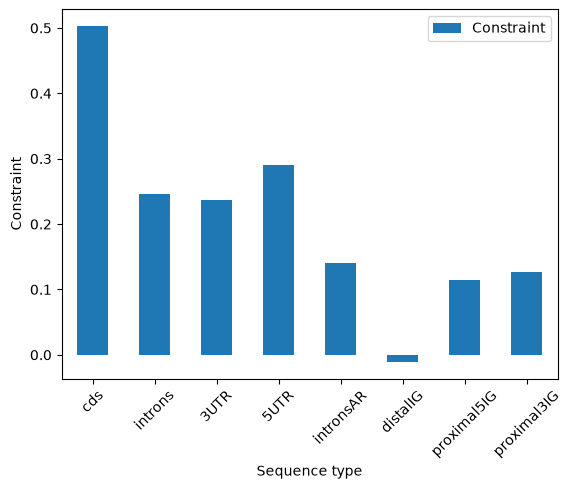

In [12]:
Constraint_data = pd.DataFrame([
    ['cds', (humanENS_cds_IGARQ - humanENS_cds)/humanENS_cds_IGARQ],
    ['introns', (humanENS_introns_IGARQ - humanENS_introns)/humanENS_introns_IGARQ],
    ['3UTR', (humanENS_3UTR_IGARQ - humanENS_3UTR)/humanENS_3UTR_IGARQ],
    ['5UTR', (humanENS_5UTR_IGARQ - humanENS_5UTR)/humanENS_5UTR_IGARQ],
    ['intronsAR', (humanENS_intronsAR_IGARQ - humanENS_intronsAR)/humanENS_intronsAR_IGARQ],
    ['distalIG', (humanENS_distalIG_IGARQ - humanENS_distalIG)/humanENS_distalIG_IGARQ],
    ['proximal5IG', (humanENS_proximal5IG_IGARQ - humanENS_proximal5IG)/humanENS_proximal5IG_IGARQ],
    ['proximal3IG', (humanENS_proximal3IG_IGARQ - humanENS_proximal3IG)/humanENS_proximal3IG_IGARQ]
    ],
    columns = ['Sequence type', 'Constraint'])


Constraint_data.plot(
    x='Sequence type',
    kind = 'bar',
    rot=45)
plt.ylabel('Constraint')

In [13]:
#Constraint_data.to_csv("Output_data/Constraint_perregion.csv", index=False)
Constraint_data

,Sequence type,Constraint
0,cds,0.503184
1,introns,0.246306
2,3UTR,0.236375
3,5UTR,0.289874
4,intronsAR,0.140400
5,distalIG,-0.010831
6,proximal5IG,0.114880
7,proximal3IG,0.125979
